# Matrix Product Operators: bulk matrix approach

In [1]:
using Pkg
Pkg.activate("../")
using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Work/Workspace/Unimi/Corsi/TN_Ulm/Materiale_dispense/TN_Notebooks`


In this notebook we build the MPO by exploting the _bulk_ matrix approach. This will lead to an exact representation of the MPO, with bond dimension that depends on the range of the Hamiltonian. In order to keep things simple, we will use a two-local Hamiltonian.

Let us consider the XY model (with $\gamma=0) in the absence of the magnetic field. We take a chain of $N=20$ spins with Hamiltonian:
$$
H = -J \sum_{i=1}^{N-1} \sigma_-^{i} \sigma_+^{i+1} + \sigma_+^{i} \sigma_-^{i+1} 
$$ 
with $J = 1.0$ setting the time-scale ($\hbar = 1$).

Notice that  the presence of a constant magnetic term would add an overall phase factor that does not alter the dynamics.


In order to build the MPO in ITensor, we need to define the system indices. This forces us to set the number of sites that in this, and following, examples will be $N=20$

In [2]:
nn = 20
jj=1.0
system = siteinds("S=1/2",nn)

20-element Vector{Index{Int64}}:
 (dim=2|id=859|"S=1/2,Site,n=1")
 (dim=2|id=215|"S=1/2,Site,n=2")
 (dim=2|id=859|"S=1/2,Site,n=3")
 (dim=2|id=241|"S=1/2,Site,n=4")
 (dim=2|id=697|"S=1/2,Site,n=5")
 (dim=2|id=478|"S=1/2,Site,n=6")
 (dim=2|id=566|"S=1/2,Site,n=7")
 (dim=2|id=897|"S=1/2,Site,n=8")
 (dim=2|id=89|"S=1/2,Site,n=9")
 (dim=2|id=365|"S=1/2,Site,n=10")
 (dim=2|id=28|"S=1/2,Site,n=11")
 (dim=2|id=281|"S=1/2,Site,n=12")
 (dim=2|id=563|"S=1/2,Site,n=13")
 (dim=2|id=216|"S=1/2,Site,n=14")
 (dim=2|id=331|"S=1/2,Site,n=15")
 (dim=2|id=237|"S=1/2,Site,n=16")
 (dim=2|id=844|"S=1/2,Site,n=17")
 (dim=2|id=885|"S=1/2,Site,n=18")
 (dim=2|id=690|"S=1/2,Site,n=19")
 (dim=2|id=992|"S=1/2,Site,n=20")

We create an empty MPO

In [54]:
M = MPO(nn)

20-element MPO:
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef
 #undef

Each tensor of the MPO, extremes excluded, is a rank-4 tensor $W_{\alpha_{i-1},\alpha_i}^{i',i}$. 

Let us consider the $i$-th element of the MPO, $1<i<N$. The bond indices $\alpha_{i-1}$ and $\alpha_i$ are, respectively, the row and column indices of the bulk, block, matrix:

$$
\begin{pmatrix}
\mathbb{1}_i & 0 & 0 & 0\\
\sigma_+^i & 0 & 0 & 0 \\
\sigma_-^i & 0 & 0 & 0 \\
0 & -J \sigma_-^i & -J\sigma_+^i &\mathbb{1}_i
\end{pmatrix}
$$

Each block of the matrix corresponds to an operator $O_{i'}^i$ that has $i'$ (output index) as row index and $i$ as column index; remind that $i$ is $i$-th element of `system`. Julia allows us to represent this block matrix as a matrix of matrices:

The form of the bulk matrix (and of the bulk vectors) is given in the Lecture Notes in Eq. 3.7 and 3.8. Note that, here, there is no magnetic term i.e. $h=0$. We need to define the operators:

In [ ]:
#Identity, spin raising and lowering operators
#We force the type to be ComplexF64 because the algebra of the spin operators involves complex numbers, and we want to ensure that all matrices are of the same type for consistency.
idMat = ComplexF64.([1.0 0.0; 0.0 1.0])
spMat = ComplexF64.([0.0 1.0; 0.0 0.0])
smMat = ComplexF64.([0.0 0.0; 1.0 0.0]) 
zeroMat = ComplexF64.([0.0 0.0; 0.0 0.0])

2×2 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im

In [15]:
appoBulk = Matrix{Matrix{ComplexF64}}(undef, 4, 4)
appoBulk[1,1] = idMat
appoBulk[1,2] = zeroMat
appoBulk[1,3] = zeroMat
appoBulk[1,4] = zeroMat 
appoBulk[2,1] = spMat
appoBulk[2,2] = zeroMat
appoBulk[2,3] = zeroMat
appoBulk[2,4] = zeroMat
appoBulk[3,1] = smMat
appoBulk[3,2] = zeroMat
appoBulk[3,3] = zeroMat
appoBulk[3,4] = zeroMat
appoBulk[4,1] = zeroMat
appoBulk[4,2] = -jj * smMat
appoBulk[4,3] = -jj * spMat
appoBulk[4,4] = idMat

2×2 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im

In [ ]:
W_bulk = Array{ComplexF64}(undef,4,4,2,2)
for ll in 1:4
    for rr in 1:4
        for mm in 1:2
            for nn in 1:2
                W_bulk[ll,rr,mm,nn] =appoBulk[ll,rr][mm,nn]
            end
        end
    end
end

You can check if this is correct: 

In [34]:
W_bulk[2,1,:,:]==spMat #Verify all the elements that you want.

true

For the extremal bulk elements (vectors) we proceed in a similar way:

In [36]:
appoVecL = Vector{Matrix{ComplexF64}}(undef, 4)
appoVecL[1] = zeroMat
appoVecL[2] = -jj * smMat
appoVecL[3] = -jj * spMat
appoVecL[4] = idMat
appoVecR = Vector{Matrix{ComplexF64}}(undef, 4)
appoVecR[1] = idMat
appoVecR[2] = spMat
appoVecR[3] = smMat
appoVecR[4] = zeroMat
leftBulk = Array{ComplexF64}(undef,4,2,2)
rightBulk = Array{ComplexF64}(undef,4,2,2)
for ll in 1:4
    for mm in 1:2
        for nn in 1:2
            leftBulk[ll,mm,nn] =appoVecL[ll][mm,nn]
            rightBulk[ll,mm,nn] =appoVecR[ll][mm,nn]
        end
    end
end

In [37]:
leftBulk[1,:,:] == zeroMat

true

Another way to obtain the same result would be:

In [24]:
bulkOp = [idMat zeroMat zeroMat zeroMat;
         spMat zeroMat zeroMat zeroMat;
         smMat zeroMat zeroMat zeroMat;
         zeroMat -jj *smMat -jj*spMat idMat]

8×8 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im   0.0+0.0im  …   0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im   0.0+0.0im      0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im   0.0+0.0im      0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im   0.0+0.0im      0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im   0.0+0.0im      0.0+0.0im  0.0+0.0im  0.0+0.0im
 1.0+0.0im  0.0+0.0im   0.0+0.0im  …   0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  -0.0-0.0im     -1.0-0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  -1.0-0.0im     -0.0-0.0im  0.0+0.0im  1.0+0.0im

Note that the result is a 8x8 matrix...

In [30]:
W_bulk2 = Array{ComplexF64}(undef,4,4,2,2) 
for a in 1:4, b in 1:4
    W_bulk2[a,b,:,:] = bulkOp[(a-1)*2+1:a*2, (b-1)*2+1:b*2]
end

In [31]:
W_bulk2 == W_bulk

true

Almost there. We have the bulk matrices defined, but we need to turn them in actual rank-4 tensors with proper indices. We are missing the key ingredients: bonds. The bonds, for the Hamiltonian we have in mind are as many as $N-1$. Each bond has dimension $4$.

In [32]:
bonds = Vector{Index}(undef, nn-1)
for j in 1:nn-1
    bonds[j] = Index(4, "Link, $j")
end

In [33]:
bonds

19-element Vector{Index}:
 (dim=4|id=357|"1,Link")
 (dim=4|id=238|"2,Link")
 (dim=4|id=53|"3,Link")
 (dim=4|id=978|"4,Link")
 (dim=4|id=735|"5,Link")
 (dim=4|id=432|"6,Link")
 (dim=4|id=893|"7,Link")
 (dim=4|id=628|"8,Link")
 (dim=4|id=784|"9,Link")
 (dim=4|id=904|"10,Link")
 (dim=4|id=315|"11,Link")
 (dim=4|id=761|"12,Link")
 (dim=4|id=397|"13,Link")
 (dim=4|id=787|"14,Link")
 (dim=4|id=30|"15,Link")
 (dim=4|id=370|"16,Link")
 (dim=4|id=447|"17,Link")
 (dim=4|id=659|"18,Link")
 (dim=4|id=864|"19,Link")

...almost there:

In [43]:
T1 = ITensor(leftBulk, bonds[1], system[1]', system[1])

ITensor ord=3 (dim=4|id=357|"1,Link") (dim=2|id=859|"S=1/2,Site,n=1")' (dim=2|id=859|"S=1/2,Site,n=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}

In [51]:
[T1[2,i,j] for i in 1:2, j in 1:2] == -jj *smMat #Verify that the (2,1) element of the left boundary tensor corresponds to the spin raising operator.

true

In [52]:
[T1[3,i,j] for i in 1:2, j in 1:2] == -jj *spMat

true

We assign the tensor T1 as the first element of the, so far empty, MPO `M`

In [55]:
M[1] = T1

ITensor ord=3 (dim=4|id=357|"1,Link") (dim=2|id=859|"S=1/2,Site,n=1")' (dim=2|id=859|"S=1/2,Site,n=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}

In [56]:
TN = ITensor(rightBulk, bonds[end], system[end]', system[end])

ITensor ord=3 (dim=4|id=864|"19,Link") (dim=2|id=992|"S=1/2,Site,n=20")' (dim=2|id=992|"S=1/2,Site,n=20")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}

Check

In [57]:
[TN[2,i,j] for i in 1:2, j in 1:2] == spMat

true

We assign `TN` to `M`

In [60]:
M[end] = TN

ITensor ord=3 (dim=4|id=864|"19,Link") (dim=2|id=992|"S=1/2,Site,n=20")' (dim=2|id=992|"S=1/2,Site,n=20")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}

For the intermediate elements the structure is:

T[k] = ITensor(W_bulk,bond[k-1],bond[k],system[k]',system[k])

In [61]:
for k=2:nn-1
    M[k] = ITensor(W_bulk, bonds[k-1], bonds[k], system[k]', system[k])
end

In [62]:
M

20-element MPO:
 ((dim=4|id=357|"1,Link"), (dim=2|id=859|"S=1/2,Site,n=1")', (dim=2|id=859|"S=1/2,Site,n=1"))
 ((dim=4|id=357|"1,Link"), (dim=4|id=238|"2,Link"), (dim=2|id=215|"S=1/2,Site,n=2")', (dim=2|id=215|"S=1/2,Site,n=2"))
 ((dim=4|id=238|"2,Link"), (dim=4|id=53|"3,Link"), (dim=2|id=859|"S=1/2,Site,n=3")', (dim=2|id=859|"S=1/2,Site,n=3"))
 ((dim=4|id=53|"3,Link"), (dim=4|id=978|"4,Link"), (dim=2|id=241|"S=1/2,Site,n=4")', (dim=2|id=241|"S=1/2,Site,n=4"))
 ((dim=4|id=978|"4,Link"), (dim=4|id=735|"5,Link"), (dim=2|id=697|"S=1/2,Site,n=5")', (dim=2|id=697|"S=1/2,Site,n=5"))
 ((dim=4|id=735|"5,Link"), (dim=4|id=432|"6,Link"), (dim=2|id=478|"S=1/2,Site,n=6")', (dim=2|id=478|"S=1/2,Site,n=6"))
 ((dim=4|id=432|"6,Link"), (dim=4|id=893|"7,Link"), (dim=2|id=566|"S=1/2,Site,n=7")', (dim=2|id=566|"S=1/2,Site,n=7"))
 ((dim=4|id=893|"7,Link"), (dim=4|id=628|"8,Link"), (dim=2|id=897|"S=1/2,Site,n=8")', (dim=2|id=897|"S=1/2,Site,n=8"))
 ((dim=4|id=628|"8,Link"), (dim=4|id=784|"9,Link"), (dim=2|

Good job folks!

## Testing

In order to test the correctness of the MPO we start by defining an MPS on $N=20$ sites with the same indices (`system`).

In [63]:
psi0= MPS(ComplexF64,system,[(j==1) ? "Up" : "Dn" for j in 1:nn]);

We introduce a bunch of function to inspect the properties of the state

In [64]:
function measureZ(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("Z", system[j])*psi[j]))
end


measureZ (generic function with 1 method)

In [65]:
@show op("Z", system[1])

op("Z", system[1]) = ITensor ord=2
Dim 1: (dim=2|id=859|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=859|"S=1/2,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}
 2×2
 1.0   0.0
 0.0  -1.0



ITensor ord=2 (dim=2|id=859|"S=1/2,Site,n=1")' (dim=2|id=859|"S=1/2,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}

In [66]:
function measureProjUp(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("ProjUp", system[j])*psi[j]))
end

function measureProjDn(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("ProjDn", system[j])*psi[j]))
end


measureProjDn (generic function with 1 method)

In [67]:
using Plots

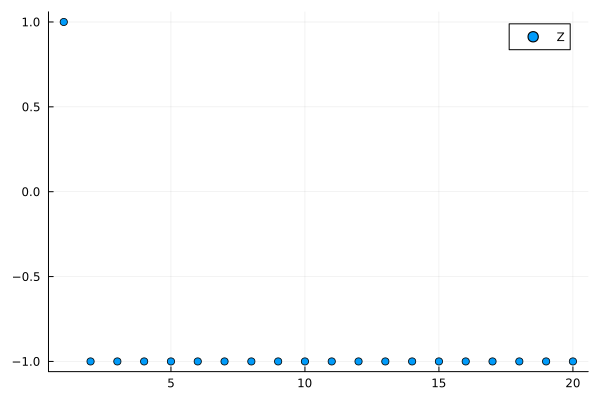

In [68]:
plot(real([measureZ(psi0,j) for j in 1:nn]), seriestype=:scatter, label="Z")

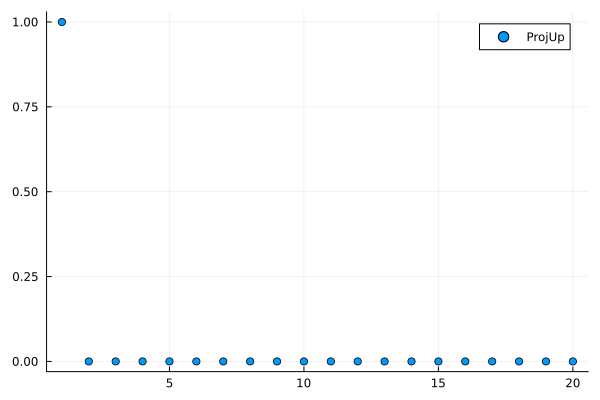

In [69]:
plot(real([measureProjUp(psi0,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

We can now see the action of the MPO on the initial state:

In [70]:
psi1 = noprime(M * psi0);
norm(psi1)

1.0

In [71]:
psi1

20-element MPS:
 ((dim=1|id=421|"Link,l=1"), (dim=2|id=859|"S=1/2,Site,n=1"))
 ((dim=2|id=215|"S=1/2,Site,n=2"), (dim=1|id=807|"Link,l=2"), (dim=1|id=421|"Link,l=1"))
 ((dim=2|id=859|"S=1/2,Site,n=3"), (dim=1|id=881|"Link,l=3"), (dim=1|id=807|"Link,l=2"))
 ((dim=2|id=241|"S=1/2,Site,n=4"), (dim=1|id=784|"Link,l=4"), (dim=1|id=881|"Link,l=3"))
 ((dim=2|id=697|"S=1/2,Site,n=5"), (dim=1|id=342|"Link,l=5"), (dim=1|id=784|"Link,l=4"))
 ((dim=2|id=478|"S=1/2,Site,n=6"), (dim=1|id=212|"Link,l=6"), (dim=1|id=342|"Link,l=5"))
 ((dim=2|id=566|"S=1/2,Site,n=7"), (dim=1|id=473|"Link,l=7"), (dim=1|id=212|"Link,l=6"))
 ((dim=2|id=897|"S=1/2,Site,n=8"), (dim=1|id=41|"Link,l=8"), (dim=1|id=473|"Link,l=7"))
 ((dim=2|id=89|"S=1/2,Site,n=9"), (dim=1|id=154|"Link,l=9"), (dim=1|id=41|"Link,l=8"))
 ((dim=2|id=365|"S=1/2,Site,n=10"), (dim=1|id=658|"Link,l=10"), (dim=1|id=154|"Link,l=9"))
 ((dim=2|id=28|"S=1/2,Site,n=11"), (dim=1|id=451|"Link,l=11"), (dim=1|id=658|"Link,l=10"))
 ((dim=2|id=281|"S=1/2,Site,n=1

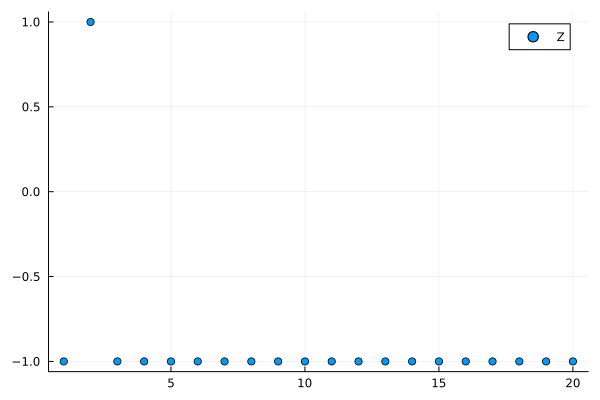

In [72]:
plot(real( [measureZ(psi1,j) for j in 1:nn]), seriestype=:scatter, label="Z")

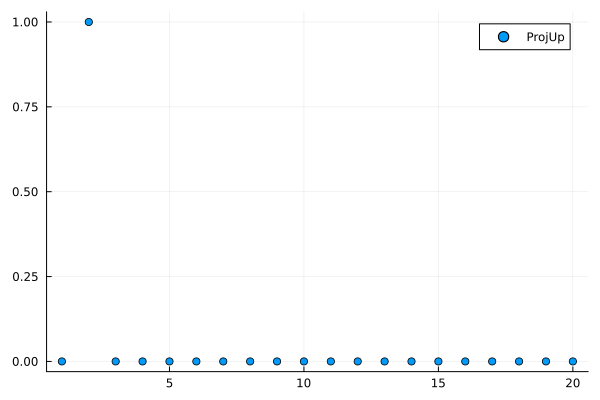

In [73]:
plot(real([measureProjUp(psi1,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

Let's apply the Hamiltonian one more time:

In [74]:
psi2 = noprime(M * psi1);
norm(psi2)

1.4142135623730951

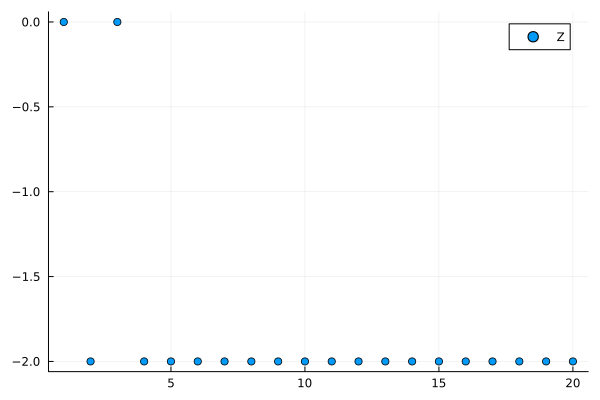

In [75]:
plot(real([measureZ(psi2,j) for j in 1:nn]), seriestype=:scatter, label="Z")

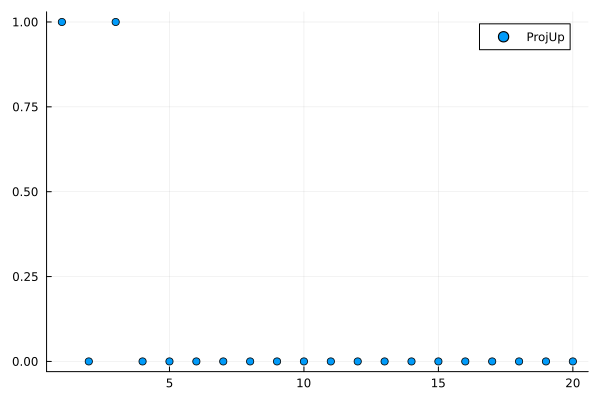

In [56]:
plot(real([measureProjUp(psi2,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

The result is not a state (lacks normalization) but looks something we can expect:

$$H \ket{2} = -jj \ket{1} - jj \ket{3}$$

...do all the tests that you deem necessary...